In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from csan import (
    make_synth_blocks,
    build_local_pool_matrix_from_grid,
    validity_first_backtest,
    load_eobs_rr,
    eobs_to_blocks,
    basic_X_diagnostics)



### Import data

In [3]:
X_np, years, grid_shape, peer_coords = make_synth_blocks(
    B=400, grid_shape=(12,12),
    p_event=.25, p_hit_given_event=.5,
    severity="pareto", pareto_alpha=1.8, pareto_scale=1.0,
    heterogeneity=.8,
    spatial_factor_strength=0.8,
    common_factor_strength=0.3,
    seed=0,
)

print(X_np.shape, years.min(), years.max(), grid_shape, peer_coords.shape)

hit_rate_per_peer = (X_np > 0).mean(axis=0)      # length n
print("avg peer hit rate:", hit_rate_per_peer.mean())
print("min/median/max peer hit rate:", hit_rate_per_peer.min(),
      np.median(hit_rate_per_peer), hit_rate_per_peer.max())

(400, 144) 1950 2349 (12, 12) (144, 2)
avg peer hit rate: 0.13597222222222222
min/median/max peer hit rate: 0.0375 0.1325 0.2375


In [9]:
# from csan import plot_peer_event_rates

# plot_peer_event_rates(X_np, grid_shape)

### Set model parameters

In [5]:
delta=0.1
eta=0.0
eps=0.2

W_local = build_local_pool_matrix_from_grid(grid_shape, radius=1, include_self=True)
# W_local = build_local_pool_matrix_from_coords(peer_coords, k=5, include_self=True)

### Split mode: time

=== Validity-first backtest (updated) ===
Pooling: local
Mode: time | Splits: 12 | nTest=25 | nC=100
Nominal coverage: 0.900
PASS rate: 1.000

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.910, std=0.035
  operational: mean=0.910, std=0.035
  identity  : mean=0.911, std=0.035

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.877 (shortfall=0.023), p05=0.883 (shortfall=0.017)
  operational : worst=0.877 (shortfall=0.023), p05=0.883 (shortfall=0.017)
  identity    : worst=0.877 (shortfall=0.023), p05=0.884 (shortfall=0.016)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.16 ± 0.0747
  mean <w,c*> (candidate)    : 1.14 ± 0.0792
  mean <w,c_op> (operational): 1.14 ± 0.0792
  AggCapRatio candidate      : 0.988 ± 0.039
  AggCapRatio operational    : 0.988 ± 0.039

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.968 ± 0.107

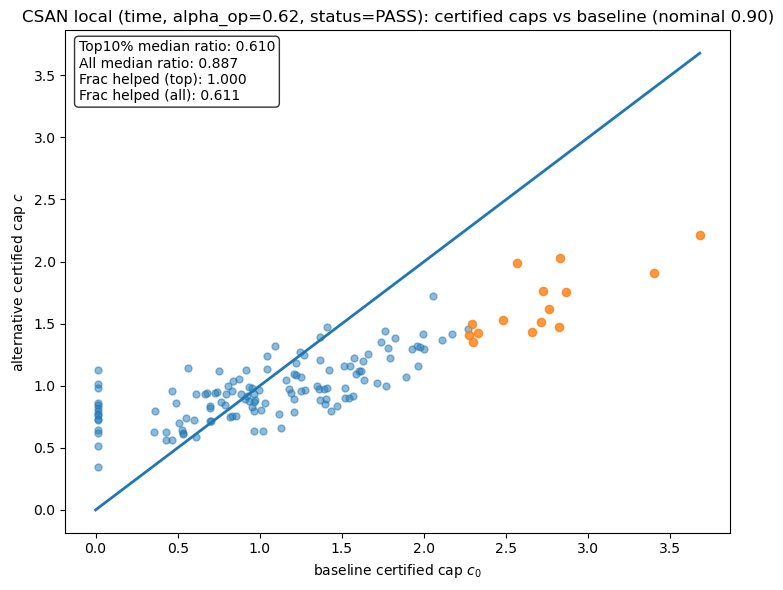

In [6]:
bt_time = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=eps,
    alphas=np.linspace(0,1,51, dtype=np.float32),
    nT=100, nV=60, nC=100, nTest=25,
    step=10,
    split_mode="time",
    make_plots=False,
    W_local=W_local,
    relief_scatter=True,
    relief_scatter_pick = "first_pass",  # "first_pass" | "median_top10" | "best_top10"
)

### Split mode: random

=== Validity-first backtest (updated) ===
Pooling: local
Mode: random | Splits: 100 | nTest=20 | nC=100
Nominal coverage: 0.900
PASS rate: 0.770

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.907, std=0.048
  operational: mean=0.909, std=0.042
  identity  : mean=0.910, std=0.040

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.891 (shortfall=0.009), p05=0.898 (shortfall=0.002)
  operational : worst=0.892 (shortfall=0.008), p05=0.897 (shortfall=0.003)
  identity    : worst=0.895 (shortfall=0.005), p05=0.899 (shortfall=0.001)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 1.04 ± 0.201
  mean <w,c*> (candidate)    : 1.02 ± 0.177
  mean <w,c_op> (operational): 1.02 ± 0.193
  AggCapRatio candidate      : 0.994 ± 0.091
  AggCapRatio operational    : 0.984 ± 0.044

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.829 ± 0.228

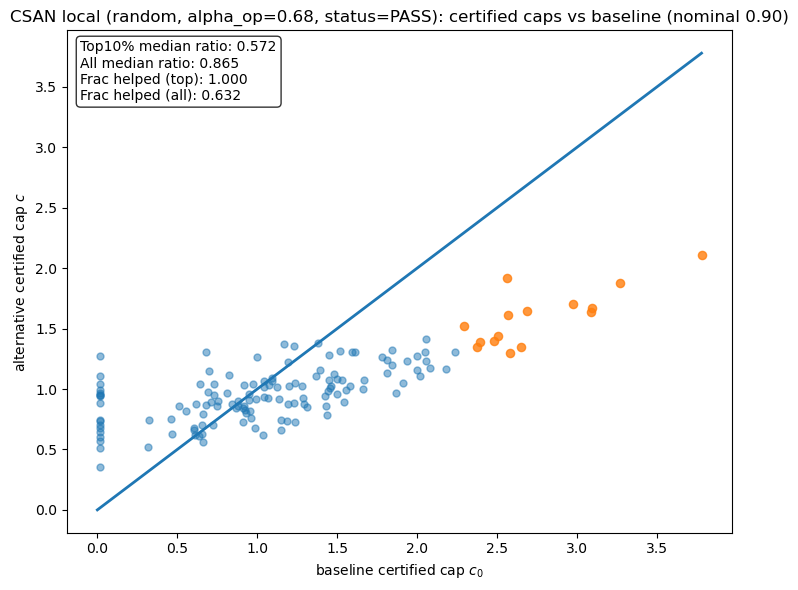

In [7]:
bt_rand = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=eps,
    alphas=np.linspace(0,1,51, dtype=np.float32),
    nT=120, nV=40, nC=100, nTest=20,
    split_mode="random",
    n_splits=100,
    seed=0,
    make_plots=False,
    W_local=W_local,
    relief_scatter=True,
    relief_scatter_pick = "first_pass",  # "first_pass" | "median_top10" | "best_top10"
)

In [8]:
from csan import print_latex_row, print_latex_identity_row

# ============================================================
# In the LOCAL notebook, run:
# ============================================================
print("% Random splits")
print_latex_row(bt_rand, "Local")

print("% Time splits")
print_latex_row(bt_time, "Local")

% Random splits
Local & 0.77 & 0.10\tiny$\pm$0.24 & 0.909 (0.897) & 0.984\tiny$\pm$0.044 & 0.939\tiny$\pm$0.148 \\
% Time splits
Local & 1.00 & 0.05\tiny$\pm$0.17 & 0.910 (0.883) & 0.988\tiny$\pm$0.039 & 0.968\tiny$\pm$0.107 \\
